# 反事实偏见（Counterfactual Bias）可视化


In [22]:
import glob
import re
from pathlib import PurePath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid', font_scale=1.05)

MODEL_COLORS = {
    'DeepSeek-V3.2':      '#4C72B0',
    'gemini-2.5-flash':   '#DD8452',
    'gpt-5-mini':         '#55A868',
    'grok-4-fast':        '#C44E52',
    'mistral-small-2603': '#8172B2',
}
MODELS_ORDER = ['DeepSeek-V3.2', 'gemini-2.5-flash', 'gpt-5-mini', 'grok-4-fast', 'mistral-small-2603']

DIM_LABELS = {
    'cf_mean_diff_overall_score':    'Overall',
    'cf_mean_diff_technical_score':  'Technical',
    'cf_mean_diff_experience_score': 'Experience',
    'cf_mean_diff_stability_score':  'Stability',
}

In [23]:
# ── 数据读取与反事实指标计算（与原 notebook 完全一致）──────────────────────
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem
    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)

if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion'].astype('string').str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )
score_cols_all = ['overall_score', 'technical_score', 'experience_score', 'stability_score']
for c in score_cols_all + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

def compute_cf_metrics(df, id_col='original_id',
                       score_cols=None, decision_col='screening_decision',
                       model_col='model'):
    if score_cols is None:
        score_cols = ['overall_score', 'technical_score', 'experience_score', 'stability_score']
    rows = []
    for model_name, d_model in df.groupby(model_col):
        grouped = d_model.groupby(id_col)
        score_diffs_dict = {c: [] for c in score_cols}
        flip_flags = []
        for oid, g in grouped:
            if len(g) < 2:
                continue
            for c in score_cols:
                scores = g[c].dropna().values
                if len(scores) > 0:
                    score_diffs_dict[c].append(float(np.max(scores) - np.min(scores)))
            decisions = g[decision_col].dropna().values
            if len(decisions) > 0:
                flip_flags.append(int(0 in set(decisions) and 1 in set(decisions)))
        row = {
            'model': model_name,
            'cf_flip_rate': np.mean(flip_flags) if flip_flags else 0.0,
            'num_resumes': len(list(grouped)),
        }
        for c in score_cols:
            row[f'cf_mean_diff_{c}'] = np.mean(score_diffs_dict[c]) if score_diffs_dict[c] else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

cf_df = compute_cf_metrics(all_df)
cf_df = cf_df.set_index('model').reindex(MODELS_ORDER).reset_index()
print('Counterfactual metrics:')
display(cf_df)

Counterfactual metrics:


,model,cf_flip_rate,num_resumes,cf_mean_diff_overall_score,cf_mean_diff_technical_score,cf_mean_diff_experience_score,cf_mean_diff_stability_score
0,DeepSeek-V3.2,0.12,50,0.76,0.36,0.78,1.38
1,gemini-2.5-flash,0.28,50,1.36,1.10,1.40,1.66
2,gpt-5-mini,0.30,50,1.40,1.40,1.40,2.20
3,grok-4-fast,0.32,50,1.36,1.06,1.50,2.06
4,mistral-small-2603,0.24,50,1.06,0.58,1.02,1.66


## 图1：四维度反事实评分差分组水平条形图

每个模型有四条横条（Overall / Technical / Experience / Stability），
按 overall 评分差升序排列

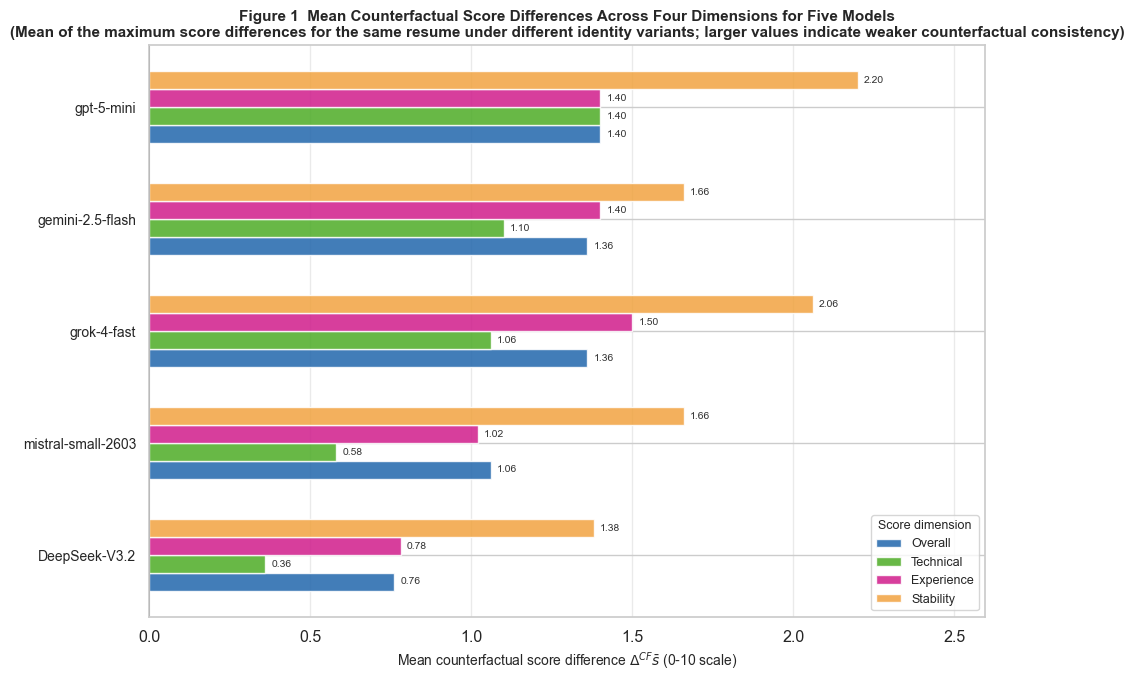

Saved: cf_fig1_grouped_bar.png


In [24]:
dim_cols = list(DIM_LABELS.keys())
dim_names = list(DIM_LABELS.values())
dim_colors = ['#2166ac', '#4dac26', '#d01c8b', '#f1a340']

# 按 overall 评分差升序排列
cf_sorted = cf_df.sort_values('cf_mean_diff_overall_score', ascending=True).reset_index(drop=True)
models = cf_sorted['model'].tolist()
n_models = len(models)
n_dims = len(dim_cols)

fig, ax = plt.subplots(figsize=(10, 7))

bar_height = 0.16
y_base = np.arange(n_models)

for di, (col, name, color) in enumerate(zip(dim_cols, dim_names, dim_colors)):
    vals = cf_sorted[col].values
    offset = (di - n_dims / 2 + 0.5) * bar_height
    bars = ax.barh(y_base + offset, vals, bar_height,
                   label=name, color=color, alpha=0.85)
    # 数值标注
    for bar, v in zip(bars, vals):
        ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', fontsize=7.5, color='#333')

ax.set_yticks(y_base)
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel('Mean counterfactual score difference $\\Delta^{CF}\\bar{s}$ (0-10 scale)', fontsize=10)
ax.set_xlim(0, cf_df[dim_cols].max().max() * 1.18)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.legend(title='Score dimension', loc='lower right', fontsize=9, title_fontsize=9)
ax.grid(axis='x', alpha=0.4)
ax.set_title('Figure 1  Mean Counterfactual Score Differences Across Four Dimensions for Five Models\n'
             '(Mean of the maximum score differences for the same resume under different identity variants; larger values indicate weaker counterfactual consistency)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('cf_fig1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cf_fig1_grouped_bar.png')

## 图2：双轴图——Overall 评分差（柱）+ 翻转率（折线）

左轴柱状图展示 overall 评分差，右轴折线展示翻转率

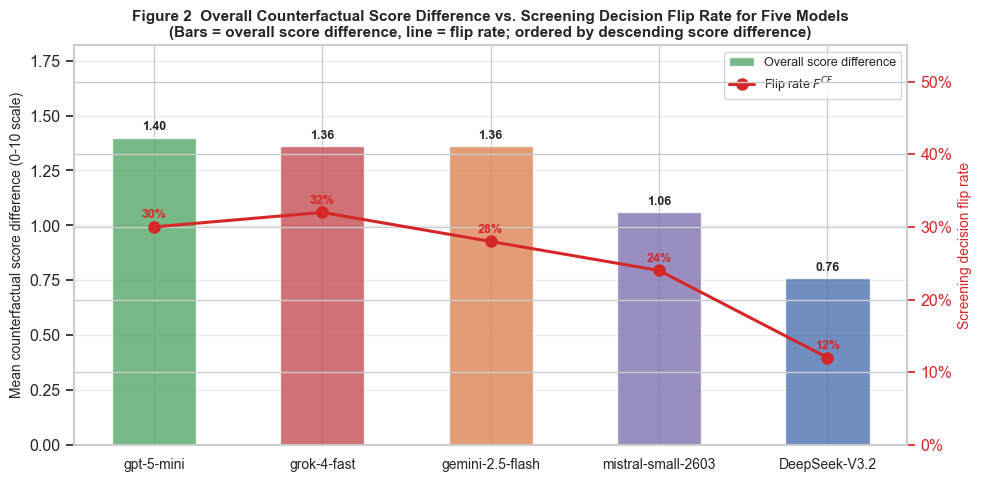

Saved: cf_fig2_dual_axis.png


In [25]:
# 按 overall 评分差降序排列（偏见最大的在左边）
cf_sorted2 = cf_df.sort_values('cf_mean_diff_overall_score', ascending=False).reset_index(drop=True)
models2 = cf_sorted2['model'].tolist()
x = np.arange(len(models2))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# 柱状图：overall 评分差
bars = ax1.bar(x, cf_sorted2['cf_mean_diff_overall_score'],
               width=0.5,
               color=[MODEL_COLORS[m] for m in models2],
               alpha=0.80, label='Overall score difference')
for bar, v in zip(bars, cf_sorted2['cf_mean_diff_overall_score']):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.02,
             f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 折线图：翻转率
ax2.plot(x, cf_sorted2['cf_flip_rate'],
         color='#d62728', marker='o', linewidth=2.2,
         markersize=8, label='Flip rate $F^{CF}$', zorder=5)
for xi, (yi, model) in enumerate(zip(cf_sorted2['cf_flip_rate'], models2)):
    ax2.text(xi, yi + 0.008, f'{yi:.0%}',
             ha='center', va='bottom', fontsize=9,
             color='#d62728', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(models2, fontsize=10)
ax1.set_ylabel('Mean counterfactual score difference (0-10 scale)', fontsize=10)
ax1.set_ylim(0, cf_df['cf_mean_diff_overall_score'].max() * 1.3)
ax2.set_ylabel('Screening decision flip rate', fontsize=10, color='#d62728')
ax2.set_ylim(0, 0.55)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.tick_params(axis='y', colors='#d62728')

# 合并图例
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.4)
ax1.set_title('Figure 2  Overall Counterfactual Score Difference vs. Screening Decision Flip Rate for Five Models\n'
              '(Bars = overall score difference, line = flip rate; ordered by descending score difference)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('cf_fig2_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cf_fig2_dual_axis.png')

## 图3：散点图——评分差 vs 翻转率

X轴 = overall 反事实评分差，Y轴 = 翻转率，
气泡大小 = stability 维度评分差（最大的维度），

每个点代表一个模型，右上角 = 两项指标均高 = 反事实偏见最严重。

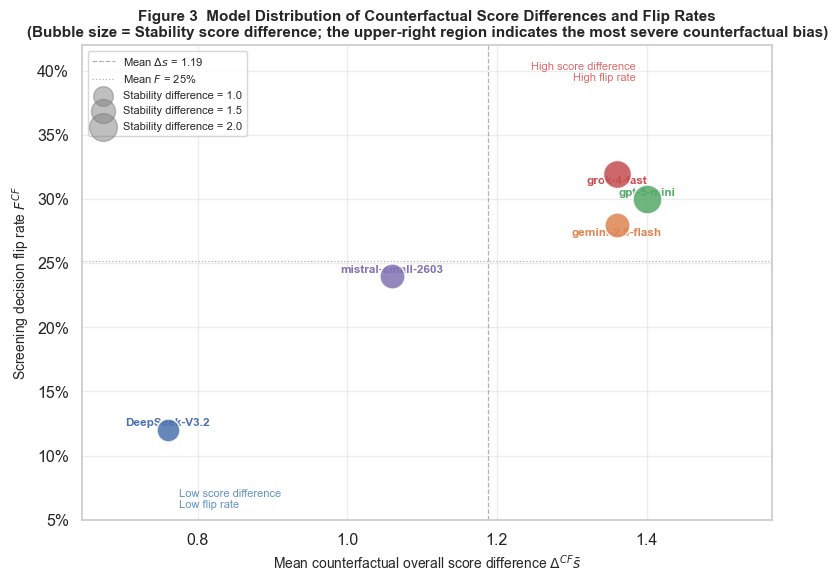

Saved: cf_fig3_scatter.png


In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in cf_df.iterrows():
    model = row['model']
    x_val = row['cf_mean_diff_overall_score']
    y_val = row['cf_flip_rate']
    size  = row['cf_mean_diff_stability_score'] * 200
    color = MODEL_COLORS.get(model, '#888')
    ax.scatter(x_val, y_val, s=size, color=color,
               alpha=0.85, edgecolors='white', linewidth=1.2, zorder=5)
    # Annotate model names with alternating vertical offsets to reduce overlap
    offset_y = 0.012 if list(cf_df['model']).index(model) % 2 == 0 else -0.018
    ax.annotate(model,
                xy=(x_val, y_val),
                xytext=(0, offset_y * 100),
                textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold',
                ha='center', va='bottom' if offset_y > 0 else 'top')

# Mean reference lines
mean_x = cf_df['cf_mean_diff_overall_score'].mean()
mean_y = cf_df['cf_flip_rate'].mean()
ax.axvline(mean_x, color='gray', linestyle='--', linewidth=0.9, alpha=0.6,
           label=f'Mean $\\Delta s$ = {mean_x:.2f}')
ax.axhline(mean_y, color='gray', linestyle=':', linewidth=0.9, alpha=0.6,
           label=f'Mean $F$ = {mean_y:.0%}')

# Quadrant annotations
x_max = cf_df['cf_mean_diff_overall_score'].max()
y_max = 0.42
y_min = 0.05
ax.text(x_max * 0.99, y_max * 0.97,
        'High score difference\nHigh flip rate', ha='right', va='top', fontsize=8,
        color='#d62728', alpha=0.7)
ax.text(cf_df['cf_mean_diff_overall_score'].min() * 1.02, y_min * 1.15,
        'Low score difference\nLow flip rate', ha='left', va='bottom', fontsize=8,
        color='#2166ac', alpha=0.7)

# Bubble size legend
for sv in [1.0, 1.5, 2.0]:
    ax.scatter([], [], s=sv*200, c='grey', alpha=0.5, label=f'Stability difference = {sv:.1f}')

ax.set_xlabel('Mean counterfactual overall score difference $\\Delta^{CF}\\bar{s}$', fontsize=10)
ax.set_ylabel('Screening decision flip rate $F^{CF}$', fontsize=10)
# Extend the y-axis range to make differences across models easier to see
ax.set_ylim(0.05, 0.42)
ax.set_xlim(cf_df['cf_mean_diff_overall_score'].min() * 0.85,
            cf_df['cf_mean_diff_overall_score'].max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.35)
ax.set_title('Figure 3  Model Distribution of Counterfactual Score Differences and Flip Rates\n'
             '(Bubble size = Stability score difference; the upper-right region indicates the most severe counterfactual bias)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('cf_fig3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cf_fig3_scatter.png')


## 图4：热力图——5模型 × 4维度反事实评分差


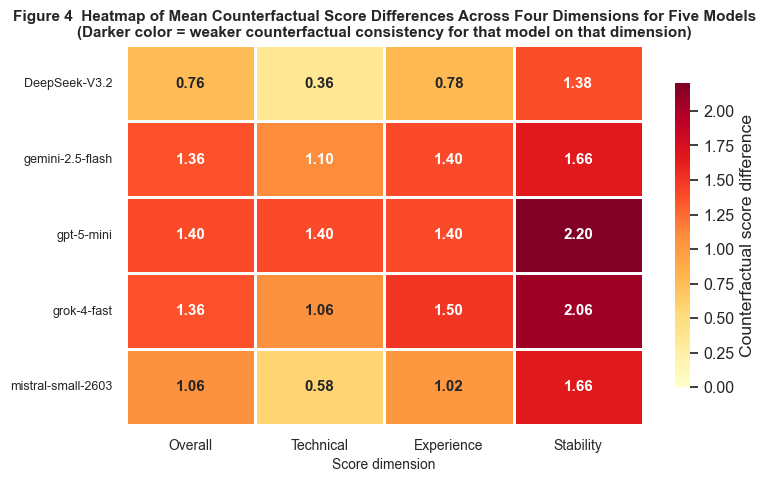

Saved: cf_fig4_heatmap.png


In [ ]:
# 构建热力图数据
heatmap_data = cf_df.set_index('model')[list(DIM_LABELS.keys())].copy()
heatmap_data.columns = list(DIM_LABELS.values())
heatmap_data = heatmap_data.reindex(MODELS_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_data, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'},
    cmap='YlOrRd',
    vmin=0, vmax=heatmap_data.values.max(),
    linewidths=0.8, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Counterfactual score difference'},
)
ax.set_title('Figure 4  Heatmap of Mean Counterfactual Score Differences Across Four Dimensions for Five Models\n'
             '(Darker color = weaker counterfactual consistency for that model on that dimension)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Score dimension', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('cf_fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cf_fig4_heatmap.png')

## 论文用表格输出

表3：五模型反事实偏见汇总
行 = 5个模型；列 = Overall/Technical/Experience/Stability 四维度评分差 + 翻转率

In [ ]:
table3 = cf_df[['model', 'cf_mean_diff_overall_score', 'cf_mean_diff_technical_score',
                'cf_mean_diff_experience_score', 'cf_mean_diff_stability_score',
                'cf_flip_rate']].copy()
table3.columns = ['Model', 'Δs̄_Overall', 'Δs̄_Technical', 'Δs̄_Experience', 'Δs̄_Stability', 'Flip Rate F^CF']
table3 = table3.set_index('Model')
print('='*65)
print('Table 3: Counterfactual Bias Summary for Five Models (sorted by ascending overall score difference)')
print('='*65)
display(table3.sort_values('Δs̄_Overall', ascending=True).round(2))

Table 3: Counterfactual Bias Summary for Five Models (sorted by ascending overall score difference)


,Δs̄_Overall,Δs̄_Technical,Δs̄_Experience,Δs̄_Stability,Flip Rate F^CF
Model,,,,,
DeepSeek-V3.2,0.76,0.36,0.78,1.38,0.12
mistral-small-2603,1.06,0.58,1.02,1.66,0.24
grok-4-fast,1.36,1.06,1.50,2.06,0.32
gemini-2.5-flash,1.36,1.10,1.40,1.66,0.28
gpt-5-mini,1.40,1.40,1.40,2.20,0.30
